# 🤖 Sentiment Analysis with BERT Transformers
### A Hands-On Advanced ML Project — Beginner Friendly

---

**What we're building:**  
A production-ready **Sentiment Analysis system** using BERT (Bidirectional Encoder Representations from Transformers) — the same technology that powers Google Search, Gmail, and modern chatbots.

**By the end of this notebook, you will:**
- ✅ Understand how Transformer models work (intuitively)
- ✅ Fine-tune a pre-trained BERT model on real data
- ✅ Evaluate it like a professional ML engineer
- ✅ Deploy it as a live web app using Gradio

**Difficulty:** 🟡 Intermediate (but explained for beginners)  
**Runtime:** ~20–30 minutes on Google Colab (free GPU)  
**Dataset:** [SST-2 / IMDB Movie Reviews](https://huggingface.co/datasets/imdb)

> 💡 **How to use this notebook:** Read the explanation cells (grey text), then run the code cells one by one. Every cell has comments explaining *what* and *why*.

## 📚 Table of Contents

| # | Section | Concept |
|---|---------|---------|
| 1 | Setup & Installation | Installing libraries |
| 2 | The Big Picture | How BERT works visually |
| 3 | Load & Explore Dataset | Data analysis |
| 4 | Tokenization | How text becomes numbers |
| 5 | Build the Model | Fine-tuning BERT |
| 6 | Training Loop | Gradient descent in action |
| 7 | Evaluation | Accuracy, F1, Confusion Matrix |
| 8 | Attention Visualization | What the model "looks at" |
| 9 | Gradio Demo App | Deploy your model live |
| 10 | What's Next | Next steps & resources |

---

## 1. 🔧 Setup & Installation

**What we're installing and why:**
- `transformers` — HuggingFace's library with 200,000+ pre-trained models (BERT, GPT, etc.)
- `datasets` — Easy access to ML benchmark datasets
- `torch` — PyTorch, the deep learning framework (pre-installed on Colab)
- `gradio` — Build interactive web UIs with 3 lines of code
- `seaborn` — Beautiful statistical visualizations

> 💡 On **Google Colab**, just run this cell. On local machine, run it in your terminal first.

In [ ]:
# Install required libraries
# This might take 1-2 minutes — perfect time to read the next markdown cell!
!pip install transformers datasets gradio seaborn scikit-learn -q

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [ ]:
# Import everything we need
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# HuggingFace ecosystem
from transformers import (
    AutoTokenizer,           # Converts text → numbers
    AutoModelForSequenceClassification,  # BERT model for classification
    TrainingArguments,       # Controls how training happens
    Trainer,                 # Handles the training loop for us
    pipeline                 # High-level inference API
)
from datasets import load_dataset

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from google.colab import userdata
userdata.get('BERT')


# ── Check if GPU is available ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Running on: {device}")
print(f"🔥 PyTorch version: {torch.__version__}")

if device.type == "cuda":
    print(f"🚀 GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU found. Training will be slow. Consider: Runtime → Change runtime type → T4 GPU")

🖥️  Running on: cuda
🔥 PyTorch version: 2.10.0+cu128
🚀 GPU detected: Tesla T4
   Memory: 15.6 GB


## 2. 🧠 The Big Picture — How BERT Works

Before writing any code, let's understand *what* we're building.

### What is Sentiment Analysis?
Given a piece of text, predict whether it's **Positive** or **Negative** (or Neutral).

```
"This movie was absolutely fantastic!"  →  😊 POSITIVE (confidence: 98%)
"Terrible acting, waste of time."       →  😞 NEGATIVE (confidence: 94%)
```

### What is BERT?
BERT stands for **B**idirectional **E**ncoder **R**epresentations from **T**ransformers.

```
Traditional models read text like this:
  "The cat sat on the mat"  →  →  →  →  →  →  →

BERT reads text like this (bidirectional):
  "The cat sat on the mat"
   ↕   ↕   ↕   ↕   ↕   ↕
  Every word attends to every other word simultaneously!
```

### The Pipeline:

```
Raw Text  →  Tokenizer  →  BERT Encoder  →  Classifier Head  →  Prediction
"I loved it"  →  [101, 1045, 2293, 2009, 102]  →  [embeddings]  →  [0.02, 0.98]  →  POSITIVE
```

### Why Fine-tuning?
BERT was pre-trained on **3.3 billion words** (Wikipedia + BookCorpus). It already understands English grammar and semantics. We just add a small classifier layer and train it on our specific task — this is called **fine-tuning**.

> 💡 **Analogy:** BERT is like a person who read every book ever written. Fine-tuning is like giving them a 1-hour crash course on movie reviews. They pick it up almost instantly!

---

## 3. 📊 Load & Explore the Dataset

We'll use the **IMDB Movie Reviews** dataset:
- 25,000 training reviews (50% positive, 50% negative)
- 25,000 test reviews
- Real reviews from IMDB users

> 💡 **Why balance matters:** If 90% of your data is positive, the model can get 90% accuracy by always predicting "positive" — without learning anything! Balanced datasets prevent this.

In [ ]:
# Load the IMDB dataset from HuggingFace Hub
# This downloads ~80MB — takes ~30 seconds
print("📥 Loading IMDB dataset...")
dataset = load_dataset("imdb")

print("\n📊 Dataset Structure:")
print(dataset)

print("\n🔍 Sample Review:")
print("-" * 60)
sample = dataset['train'][0]
print(f"Label: {'POSITIVE ✅' if sample['label'] == 1 else 'NEGATIVE ❌'}")
print(f"Review: {sample['text'][:300]}...")

📥 Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


📊 Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

🔍 Sample Review:
------------------------------------------------------------
Label: NEGATIVE ❌
Review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


Training samples: 3000
Test samples:     500


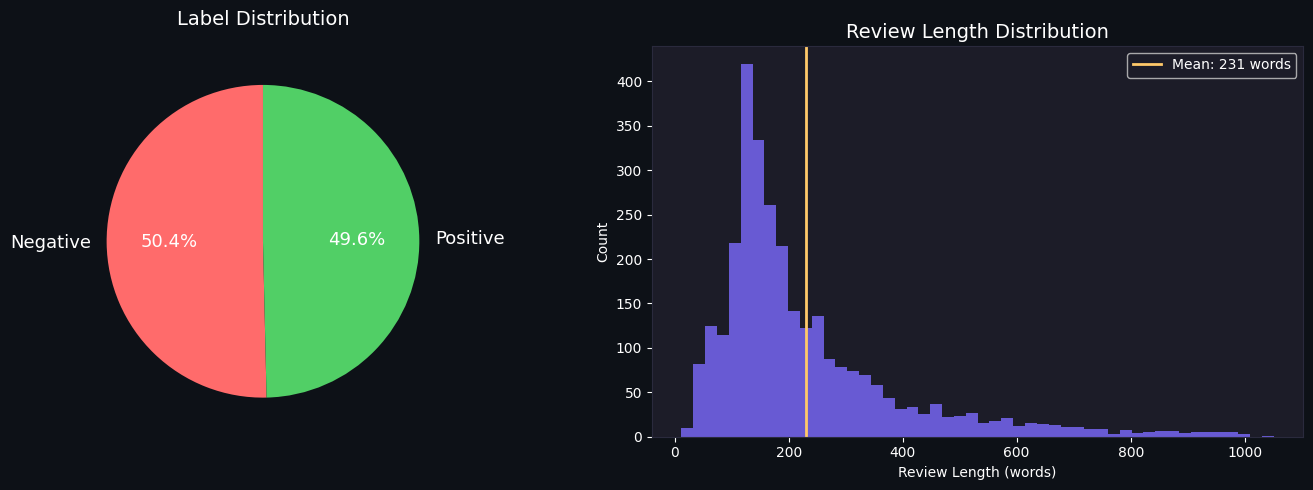


📏 Average review length: 231 words
📏 Max review length: 1051 words
📏 Min review length: 12 words


In [ ]:
# ── Explore the data ──
# Let's understand what we're working with before training

# For faster training in this demo, we'll use a subset
# In production, use the full dataset!
train_data = dataset['train'].shuffle(seed=42).select(range(3000))
test_data  = dataset['test'].shuffle(seed=42).select(range(500))

print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")

# ── Label Distribution ──
train_labels = train_data['label']
label_counts = Counter(train_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Chart 1: Label distribution
colors = ['#ff6b6b', '#51cf66']
labels_names = ['Negative', 'Positive']
axes[0].pie(
    [label_counts[0], label_counts[1]],
    labels=labels_names, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 13}
)
axes[0].set_title('Label Distribution', color='white', fontsize=14, pad=15)
axes[0].set_facecolor('#0d1117')

# Chart 2: Review length distribution
review_lengths = [len(text.split()) for text in train_data['text']]
axes[1].hist(review_lengths, bins=50, color='#7c6aff', alpha=0.8, edgecolor='none')
axes[1].axvline(np.mean(review_lengths), color='#ffc96a', linewidth=2,
                label=f'Mean: {np.mean(review_lengths):.0f} words')
axes[1].set_xlabel('Review Length (words)', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].set_title('Review Length Distribution', color='white', fontsize=14)
axes[1].legend(facecolor='#1c1c28', labelcolor='white')
axes[1].set_facecolor('#1c1c28')
axes[1].tick_params(colors='white')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#2a2a3d')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\n📏 Average review length: {np.mean(review_lengths):.0f} words")
print(f"📏 Max review length: {max(review_lengths)} words")
print(f"📏 Min review length: {min(review_lengths)} words")

In [ ]:
# ── Look at some examples ──
print("🔍 SAMPLE REVIEWS\n")
print("=" * 70)

for i in range(4):
    sample = train_data[i]
    sentiment = "✅ POSITIVE" if sample['label'] == 1 else "❌ NEGATIVE"
    text = sample['text']
    # Truncate for display
    display_text = text[:250] + "..." if len(text) > 250 else text
    print(f"\n[{sentiment}]")
    print(f"  {display_text}")
    print("-" * 70)

🔍 SAMPLE REVIEWS


[✅ POSITIVE]
  There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier ...
----------------------------------------------------------------------

[✅ POSITIVE]
  This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub your toe on the moon" It reminds me of Sinatra's so...
----------------------------------------------------------------------

[❌ NEGATIVE]
  George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this movie continues the fairy story of the oh-so innocen...
------------------------------

## 4. ✂️ Tokenization — How Text Becomes Numbers

Computers don't understand words. They understand numbers.

A **tokenizer** converts text into a sequence of integer IDs that BERT can process.

```
"I love this movie!"
        ↓  (tokenize)
['[CLS]', 'i', 'love', 'this', 'movie', '!', '[SEP]']
        ↓  (convert to IDs)
[  101,  1045, 2293, 2023, 3185,  999,  102]
```

**Special tokens:**
- `[CLS]` (ID: 101) — Start token. BERT uses this token's final representation for classification!
- `[SEP]` (ID: 102) — Separator token. Marks the end of a sequence.

**What is WordPiece tokenization?**
BERT splits unknown words into subwords:
```
"unbelievable" → ['un', '##believe', '##able']
```
This handles rare words and typos gracefully!

In [ ]:
# Load the BERT tokenizer
# 'bert-base-uncased' = BERT with lowercase text, 110M parameters
MODEL_NAME = "bert-base-uncased"

print(f"📥 Loading tokenizer for: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Demo: Watch tokenization in action ──
examples = [
    "I absolutely loved this film!",
    "Terrible movie, complete waste of time.",
    "The cinematography was unbelievably beautiful."
]

print("\n🔬 TOKENIZATION DEMO")
print("=" * 60)

for text in examples:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text)
    print(f"\nInput: '{text}'")
    print(f"Tokens: {tokens}")
    print(f"IDs:    {ids}")
    print(f"Length: {len(ids)} tokens")

📥 Loading tokenizer for: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


🔬 TOKENIZATION DEMO

Input: 'I absolutely loved this film!'
Tokens: ['i', 'absolutely', 'loved', 'this', 'film', '!']
IDs:    [101, 1045, 7078, 3866, 2023, 2143, 999, 102]
Length: 8 tokens

Input: 'Terrible movie, complete waste of time.'
Tokens: ['terrible', 'movie', ',', 'complete', 'waste', 'of', 'time', '.']
IDs:    [101, 6659, 3185, 1010, 3143, 5949, 1997, 2051, 1012, 102]
Length: 10 tokens

Input: 'The cinematography was unbelievably beautiful.'
Tokens: ['the', 'cinematography', 'was', 'un', '##bel', '##ie', '##va', '##bly', 'beautiful', '.']
IDs:    [101, 1996, 16434, 2001, 4895, 8671, 2666, 3567, 6321, 3376, 1012, 102]
Length: 12 tokens


In [ ]:
# ── Tokenize the entire dataset ──
MAX_LENGTH = 128  # BERT max is 512, but 128 is faster and sufficient for most reviews

def tokenize_function(examples):
    """
    This function processes batches of text.
    - truncation=True: cut reviews longer than MAX_LENGTH
    - padding='max_length': pad short reviews with zeros to MAX_LENGTH
    - return_tensors: we'll convert to tensors during training
    """
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )

print("⚙️  Tokenizing training data...")
tokenized_train = train_data.map(tokenize_function, batched=True, batch_size=500)

print("⚙️  Tokenizing test data...")
tokenized_test = test_data.map(tokenize_function, batched=True, batch_size=500)

# Set format for PyTorch
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test  = tokenized_test.rename_column("label", "labels")
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_test.set_format('torch',  columns=['input_ids', 'attention_mask', 'labels'])

print("\n✅ Tokenization complete!")
print(f"Training set: {len(tokenized_train)} samples")
print(f"Test set:     {len(tokenized_test)} samples")

# ── Visualize what a tokenized input looks like ──
sample = tokenized_train[0]
print(f"\n📊 Tokenized sample shape:")
print(f"  input_ids shape:      {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label:                {sample['labels'].item()} ({'POS' if sample['labels'] == 1 else 'NEG'})")

⚙️  Tokenizing training data...


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

⚙️  Tokenizing test data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]


✅ Tokenization complete!
Training set: 3000 samples
Test set:     500 samples

📊 Tokenized sample shape:
  input_ids shape:      torch.Size([128])
  attention_mask shape: torch.Size([128])
  label:                1 (POS)


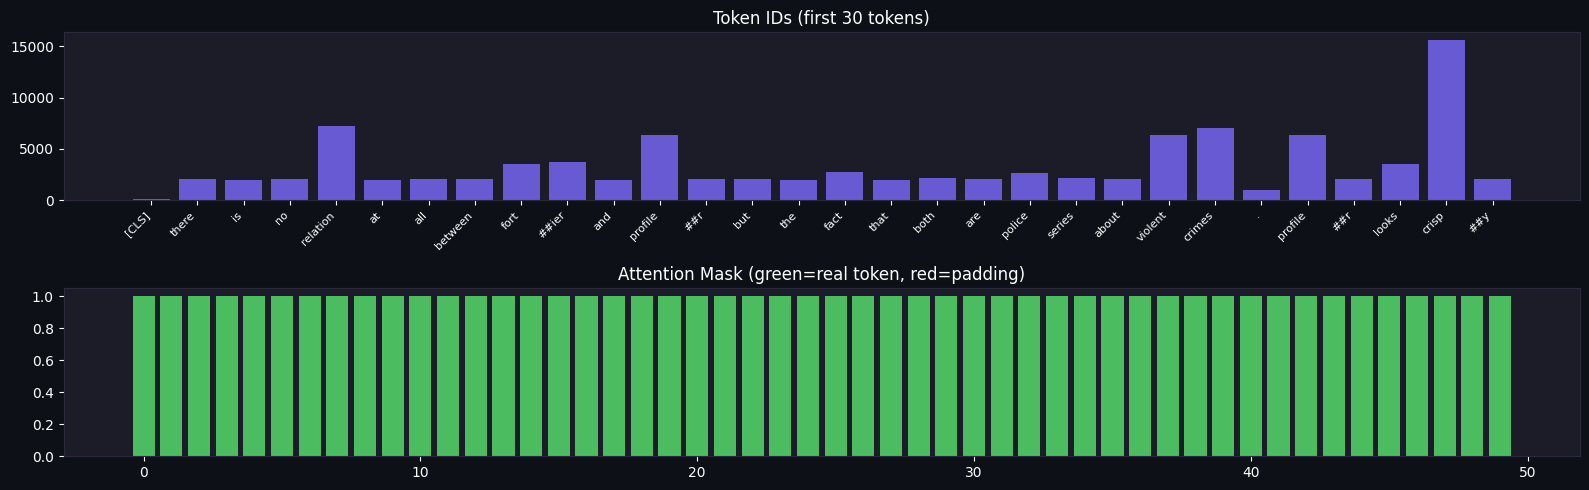

In [ ]:
# ── Visualize attention mask ──
# The attention mask tells BERT which tokens are real vs padding
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

sample = tokenized_train[0]
input_ids = sample['input_ids'].numpy()
attn_mask = sample['attention_mask'].numpy()

# Get actual tokens
token_list = tokenizer.convert_ids_to_tokens(input_ids[:30])

# Plot input IDs (first 30)
ax1.bar(range(30), input_ids[:30], color='#7c6aff', alpha=0.8)
ax1.set_xticks(range(30))
ax1.set_xticklabels(token_list, rotation=45, ha='right', fontsize=8, color='white')
ax1.set_title('Token IDs (first 30 tokens)', color='white', fontsize=12)
ax1.set_facecolor('#1c1c28')
ax1.tick_params(colors='white')
for spine in ax1.spines.values(): spine.set_edgecolor('#2a2a3d')

# Plot attention mask
colors_mask = ['#51cf66' if m == 1 else '#ff6b6b' for m in attn_mask[:50]]
ax2.bar(range(50), attn_mask[:50], color=colors_mask, alpha=0.9)
ax2.set_title('Attention Mask (green=real token, red=padding)', color='white', fontsize=12)
ax2.set_facecolor('#1c1c28')
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#2a2a3d')

plt.tight_layout()
plt.savefig('tokenization_viz.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. 🏗️ Building the Model — Fine-tuning BERT

We're not training BERT from scratch (that took Google weeks and millions of dollars). Instead, we:

1. **Load** the pre-trained BERT model (weights already learned from 3.3B words)
2. **Add** a small classification head on top (just a linear layer)
3. **Fine-tune** — update all weights slightly on our sentiment data

```
BERT Pre-trained Weights (frozen/updated slightly)
        ┌─────────────────────────────────┐
Input   │  [CLS] I loved this movie [SEP] │
        │           ↓↓↓↓↓↓               │
        │    Transformer Layers ×12       │  ← BERT body
        │    (Self-Attention + FFN)       │
        │           ↓↓↓↓                 │
        │    [CLS] representation         │
        └─────────────────────────────────┘
                    ↓
        ┌──────────────────────┐
        │   Linear(768 → 2)    │  ← NEW head we add
        │   Softmax            │
        └──────────────────────┘
                    ↓
           [0.02, 0.98] → POSITIVE
```

**Why use `bert-base-uncased`?**
- `base` = 12 layers, 110M parameters (vs `large` = 24 layers, 340M)
- `uncased` = lowercase input (simpler, often sufficient)
- Good balance of speed vs performance

In [ ]:
# Load the pre-trained BERT model with a classification head
# We add attn_implementation="eager" to allow extracting attention maps for visualization

print(f"📥 Loading {MODEL_NAME} model...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,                    # Binary classification
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
    attn_implementation="eager"      # Required for output_attentions=True to work
)

model.to(device)  # Send to GPU if available

# ── Count parameters ──
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n📊 Model Architecture Summary:")
print("=" * 50)
print(f"Total parameters:     {total_params:,}  ({total_params/1e6:.1f}M)")
print(f"Trainable parameters: {trainable_params:,}  ({trainable_params/1e6:.1f}M)")
print(f"Model device:         {next(model.parameters()).device}")

# Show the classifier head structure
print("\n🔍 Classifier Head (what we added):")
print(model.classifier)

📥 Loading bert-base-uncased model...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Model Architecture Summary:
Total parameters:     109,483,778  (109.5M)
Trainable parameters: 109,483,778  (109.5M)
Model device:         cuda:0

🔍 Classifier Head (what we added):
Linear(in_features=768, out_features=2, bias=True)


## 6. 🏋️ Training the Model

Training has 3 phases per **step**:

```
1. FORWARD PASS  → feed batch through model → get predictions
2. COMPUTE LOSS  → compare predictions to true labels (Cross-Entropy Loss)
3. BACKWARD PASS → compute gradients (backpropagation)
4. UPDATE        → adjust weights using optimizer (AdamW)
```

**Key hyperparameters:**
| Parameter | Value | Why |
|-----------|-------|-----|
| `learning_rate` | 2e-5 | Small because BERT is already trained — we nudge, not overwrite |
| `num_train_epochs` | 3 | Usually 2-4 epochs is enough for fine-tuning |
| `per_device_train_batch_size` | 16 | How many samples per GPU step |
| `warmup_steps` | 100 | Gradually increase LR at start for stable training |
| `weight_decay` | 0.01 | L2 regularization to prevent overfitting |

> 💡 **Epoch vs Step:** One epoch = one full pass through the training data. One step = one batch update.

In [ ]:
# ── Define evaluation metrics ──
def compute_metrics(eval_pred):
    """
    Called automatically by the Trainer after each evaluation.
    eval_pred contains (logits, labels) — logits are raw scores before softmax.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)  # Pick class with highest score

    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': acc,
        'f1': f1
    }

# ── Configure training ──
training_args = TrainingArguments(
    output_dir='./bert-sentiment-model',   # Where to save checkpoints

    # Training schedule
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # Learning rate & optimization
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,

    # Evaluation
    eval_strategy="epoch",      # Evaluate after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',

    # Logging
    logging_dir='./logs',
    logging_steps=50,
    report_to="none",           # Disable W&B for this demo

    # Speed
    fp16=torch.cuda.is_available(),  # Use 16-bit precision on GPU (2× faster)
)

print("✅ Training configuration set!")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Batch size: {training_args.per_device_train_batch_size}")
print(f"   Learning rate: {training_args.learning_rate}")
print(f"   FP16 (half-precision): {training_args.fp16}")

estimated_steps = (len(tokenized_train) // training_args.per_device_train_batch_size) * training_args.num_train_epochs
print(f"\n⏱️  Estimated total steps: {estimated_steps}")
print(f"⏱️  Estimated time: ~{estimated_steps * 0.3 / 60:.0f}–{estimated_steps * 0.5 / 60:.0f} minutes on GPU")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training configuration set!
   Epochs: 3
   Batch size: 16
   Learning rate: 2e-05
   FP16 (half-precision): True

⏱️  Estimated total steps: 561
⏱️  Estimated time: ~3–5 minutes on GPU


In [ ]:
# ── Initialize the Trainer ──
# HuggingFace's Trainer handles the entire training loop:
# batching, gradient updates, evaluation, checkpointing — all automatic!

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("🚀 Starting training...")
print("=" * 60)
print("  Watch the 'loss' decrease and 'accuracy' increase!")
print("  Training loss → 0 means the model is learning")
print("=" * 60)

# ── TRAIN! ──
train_result = trainer.train()

print("\n🎉 Training complete!")
print(f"   Final training loss: {train_result.training_loss:.4f}")
print(f"   Total training time: {train_result.metrics['train_runtime']:.0f} seconds")

🚀 Starting training...
  Watch the 'loss' decrease and 'accuracy' increase!
  Training loss → 0 means the model is learning


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.391765,0.356772,0.836000,0.834732
2,0.254617,0.337980,0.862000,0.861849
3,0.152907,0.479522,0.868000,0.867837


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


🎉 Training complete!
   Final training loss: 0.3120
   Total training time: 126 seconds


## 7. 📊 Evaluation — How Good Is Our Model?

After training, we rigorously evaluate on **unseen data** (the test set).

**Key metrics:**
- **Accuracy** — What % of predictions are correct?
- **Precision** — Of all predicted positives, how many are truly positive?
- **Recall** — Of all true positives, how many did we catch?
- **F1 Score** — Harmonic mean of precision & recall. Best single metric.
- **Confusion Matrix** — Visual breakdown of errors

In [ ]:
# ── Run evaluation on test set ──
print("🔍 Evaluating on test set...")
eval_results = trainer.evaluate(tokenized_test)

print("\n📊 EVALUATION RESULTS")
print("=" * 40)
for key, val in eval_results.items():
    if isinstance(val, float):
        print(f"  {key:30s}: {val:.4f}")

# ── Get predictions for detailed analysis ──
predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids
probs = torch.softmax(torch.tensor(predictions_output.predictions), dim=-1).numpy()

print("\n📋 DETAILED CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(true_labels, preds, target_names=['NEGATIVE', 'POSITIVE']))

🔍 Evaluating on test set...



📊 EVALUATION RESULTS
  eval_loss                     : 0.4795
  eval_accuracy                 : 0.8680
  eval_f1                       : 0.8678
  eval_runtime                  : 1.2263
  eval_samples_per_second       : 407.7380
  eval_steps_per_second         : 13.0480
  epoch                         : 3.0000

📋 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    NEGATIVE       0.91      0.83      0.86       254
    POSITIVE       0.84      0.91      0.87       246

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500



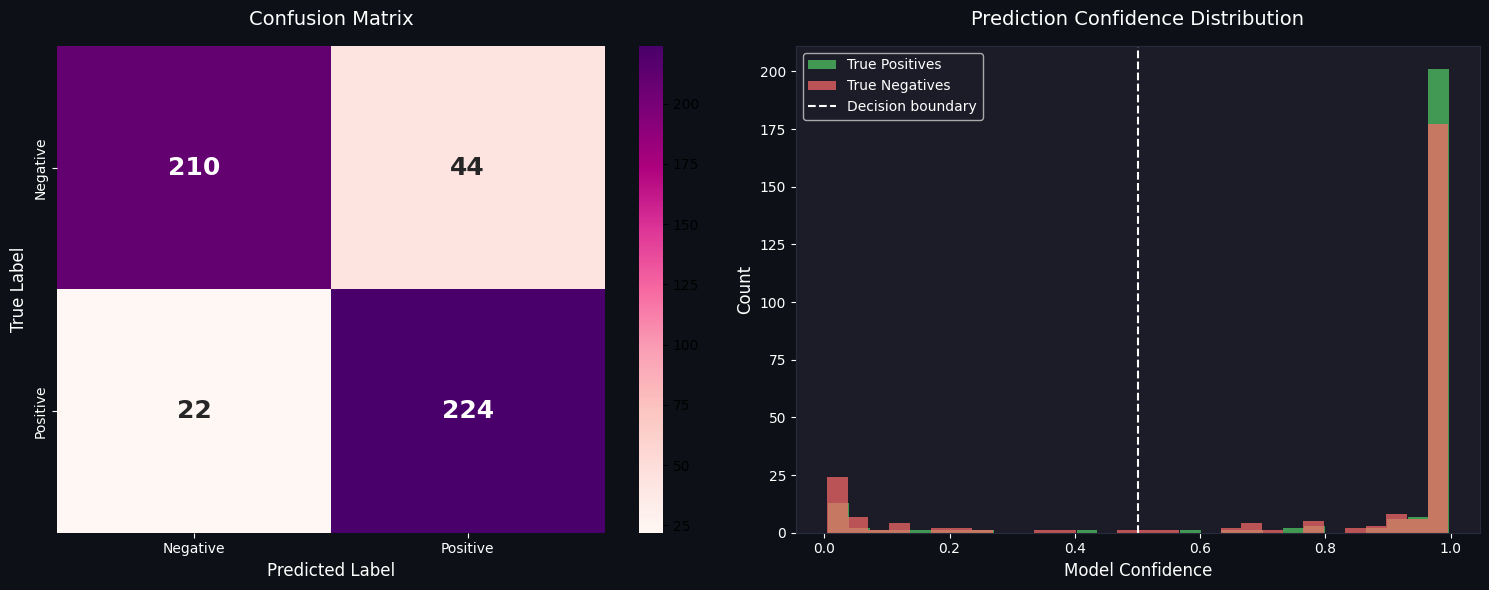


📈 Confusion Matrix Breakdown:
  True Positives  (correctly predicted POS): 224
  True Negatives  (correctly predicted NEG): 210
  False Positives (predicted POS, was NEG):  44  ← Type I Error
  False Negatives (predicted NEG, was POS):  22  ← Type II Error


In [ ]:
# ── Plot Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='RdPu',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=axes[0],
    annot_kws={'size': 18, 'weight': 'bold'}
)
axes[0].set_xlabel('Predicted Label', color='white', fontsize=12)
axes[0].set_ylabel('True Label', color='white', fontsize=12)
axes[0].set_title('Confusion Matrix', color='white', fontsize=14, pad=15)
axes[0].set_facecolor('#1c1c28')
axes[0].tick_params(colors='white')

# ── Confidence Distribution ──
pos_confidences = probs[:, 1][true_labels == 1]  # Predicted prob of POS for true POS
neg_confidences = probs[:, 0][true_labels == 0]  # Predicted prob of NEG for true NEG

axes[1].hist(pos_confidences, bins=30, alpha=0.7, color='#51cf66',
             label='True Positives', edgecolor='none')
axes[1].hist(neg_confidences, bins=30, alpha=0.7, color='#ff6b6b',
             label='True Negatives', edgecolor='none')
axes[1].axvline(0.5, color='white', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[1].set_xlabel('Model Confidence', color='white', fontsize=12)
axes[1].set_ylabel('Count', color='white', fontsize=12)
axes[1].set_title('Prediction Confidence Distribution', color='white', fontsize=14, pad=15)
axes[1].legend(facecolor='#1c1c28', labelcolor='white', fontsize=10)
axes[1].set_facecolor('#1c1c28')
axes[1].tick_params(colors='white')
for spine in axes[1].spines.values(): spine.set_edgecolor('#2a2a3d')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Summary
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Confusion Matrix Breakdown:")
print(f"  True Positives  (correctly predicted POS): {tp}")
print(f"  True Negatives  (correctly predicted NEG): {tn}")
print(f"  False Positives (predicted POS, was NEG):  {fp}  ← Type I Error")
print(f"  False Negatives (predicted NEG, was POS):  {fn}  ← Type II Error")

In [ ]:
# ── Error Analysis: Look at the mistakes ──
print("🔍 HARD CASES — Reviews the model got wrong\n")
print("=" * 70)

wrong_idx = np.where(preds != true_labels)[0]
# Show up to 5 mistakes
for i in wrong_idx[:5]:
    text = test_data[int(i)]['text']
    true_label = "POSITIVE" if true_labels[i] == 1 else "NEGATIVE"
    pred_label = "POSITIVE" if preds[i] == 1 else "NEGATIVE"
    confidence = probs[i][preds[i]]

    print(f"True: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.2%}")
    print(f"Review: {text[:200]}...")
    print("-" * 70)

print(f"\n💡 These 'hard cases' are often:")
print("  - Sarcastic reviews ('Oh great, another terrible movie...')")
print("  - Mixed-sentiment reviews ('Good acting but terrible plot')")
print("  - Very short reviews without enough context")

🔍 HARD CASES — Reviews the model got wrong

True: NEGATIVE | Predicted: POSITIVE | Confidence: 99.17%
Review: Coming from Kiarostami, this art-house visual and sound exposition is a surprise. For a director known for his narratives and keen observation of humans, especially children, this excursion into minim...
----------------------------------------------------------------------
True: NEGATIVE | Predicted: POSITIVE | Confidence: 87.73%
Review: This is about some vampires (who can run around out in the sunlight), that are causing some problems down in South America. Casper Van Dien is sent in with his team of commandos to investigate. The mo...
----------------------------------------------------------------------
True: POSITIVE | Predicted: NEGATIVE | Confidence: 86.73%
Review: It is to typical of people complaining about something when they no nothing about it...So this is about a gay man falling for a straight women. First of all...This is a true story so you cant say its ...
----

## 8. 🔭 Attention Visualization — What Is the Model Looking At?

This is where it gets really cool. We can actually **visualize** which words the model pays most attention to when making a prediction.

> 💡 BERT has **12 attention heads** across **12 layers**. Each head specializes in different linguistic relationships (syntax, coreference, semantics). We'll visualize one head's attention pattern.


Analyzing: 'This film was absolutely breathtaking and emotionally powerf...'


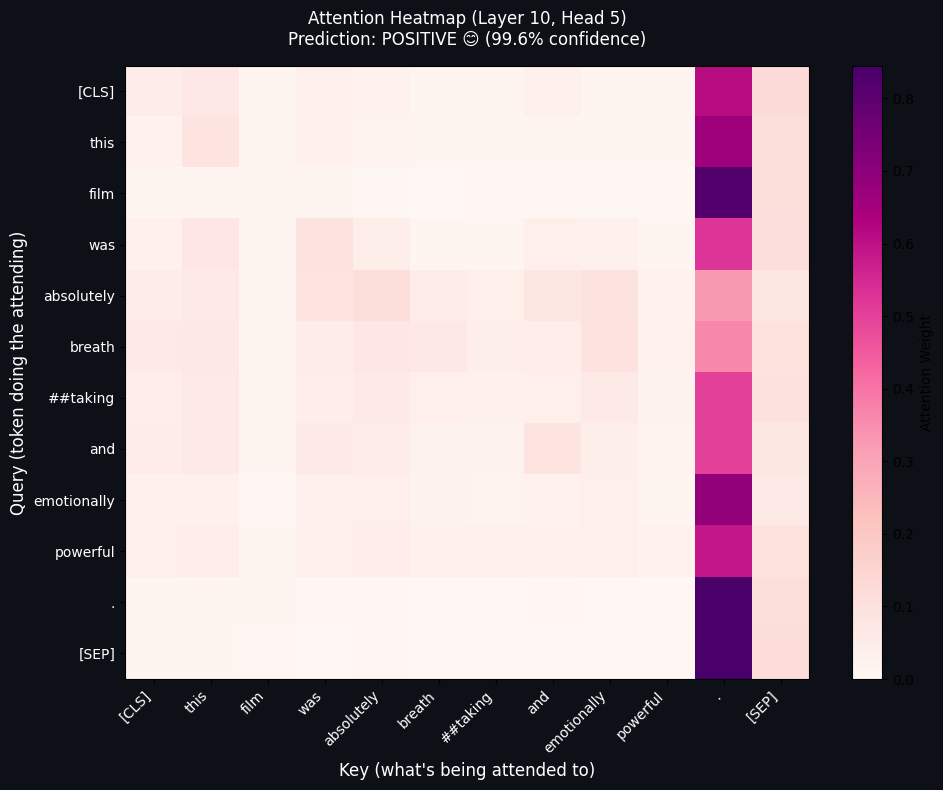

Prediction: POSITIVE 😊 (99.6%)

Analyzing: 'Complete waste of money. Terrible script and bad acting....'


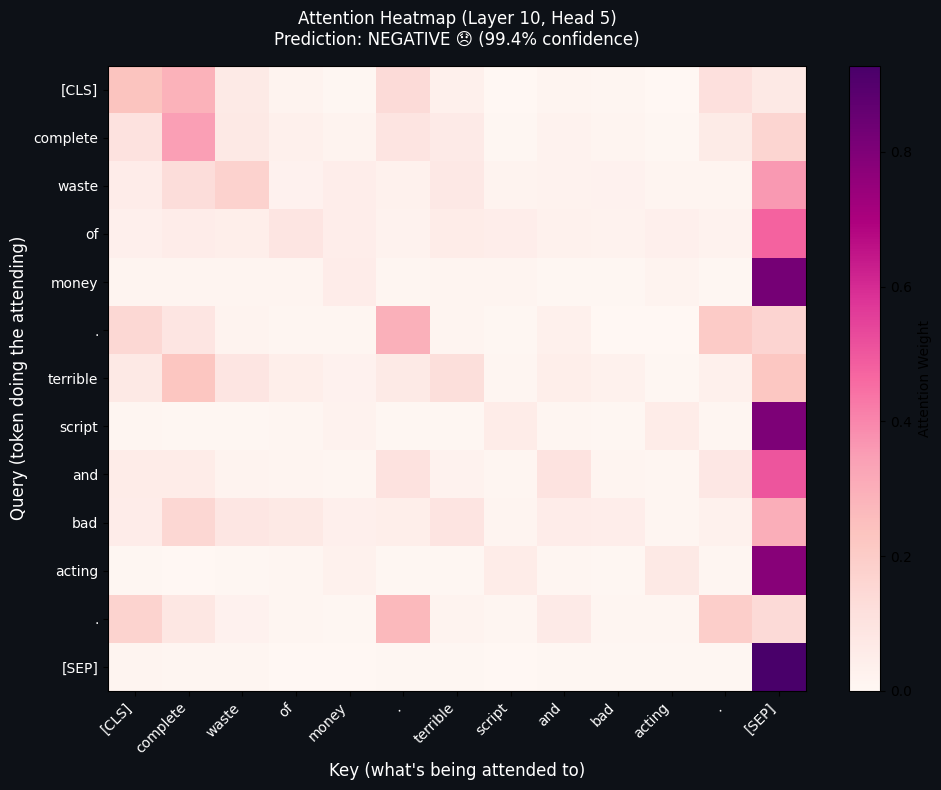

Prediction: NEGATIVE 😞 (99.4%)


In [ ]:
def visualize_attention(text, layer=10, head=5):
    """
    Visualize BERT's attention weights for a given input text.
    """
    # Tokenize
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=30).to(device)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Get attention weights (output_attentions=True)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # Extract attention: shape = (layers, batch, heads, seq_len, seq_len)
    # Check if attentions exist to avoid NoneType error
    if outputs.attentions is None:
        print("❌ Error: Model did not return attention weights. Ensure it was loaded with attn_implementation='eager'.")
        return None, None

    attn = outputs.attentions[layer][0, head].cpu().numpy()

    # Get prediction
    pred = torch.softmax(outputs.logits, dim=-1)
    pred_class = "POSITIVE 😊" if pred[0][1] > 0.5 else "NEGATIVE 😞"
    confidence = pred[0].max().item()

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0d1117')

    # Trim tokens (remove padding)
    n_tokens = min(len(tokens), 20)
    attn_trimmed = attn[:n_tokens, :n_tokens]
    tokens_trimmed = tokens[:n_tokens]

    im = ax.imshow(attn_trimmed, cmap='RdPu', aspect='auto', vmin=0, vmax=attn_trimmed.max())
    plt.colorbar(im, ax=ax, label='Attention Weight')

    ax.set_xticks(range(n_tokens))
    ax.set_yticks(range(n_tokens))
    ax.set_xticklabels(tokens_trimmed, rotation=45, ha='right', color='white', fontsize=10)
    ax.set_yticklabels(tokens_trimmed, color='white', fontsize=10)
    ax.set_xlabel("Key (what's being attended to)", color='white', fontsize=12)
    ax.set_ylabel("Query (token doing the attending)", color='white', fontsize=12)

    title = f'Attention Heatmap (Layer {layer}, Head {head})\n'
    title += f'Prediction: {pred_class} ({confidence:.1%} confidence)'
    ax.set_title(title, color='white', fontsize=12, pad=15)
    ax.set_facecolor('#1c1c28')

    plt.tight_layout()
    plt.savefig('attention_viz.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

    return pred_class, confidence

# ── Test it! ──
test_reviews = [
    "This film was absolutely breathtaking and emotionally powerful.",
    "Complete waste of money. Terrible script and bad acting.",
]

for review in test_reviews:
    print(f"\nAnalyzing: '{review[:60]}...'")
    pred, conf = visualize_attention(review)
    if pred: print(f"Prediction: {pred} ({conf:.1%})")

## 9. 🚀 Deploy as a Live Web App with Gradio

Now let's wrap everything into a beautiful interactive demo anyone can use — no code required!

Gradio creates a web interface with just a few lines of Python. You'll get:
- A public shareable URL (works for 72 hours on Colab)
- An interactive text input
- Real-time predictions with confidence scores
- Attention visualization

In [ ]:
import gradio as gr

# ── Create inference pipeline for fast predictions ──
# HuggingFace pipeline handles tokenization + inference in one call
sentiment_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True  # Return scores for both classes
)

def predict_sentiment(text):
    """
    Main prediction function called by Gradio.
    Returns formatted results for display.
    """
    if not text.strip():
        return "Please enter some text!", {}, ""

    # Get predictions
    results = sentiment_pipeline(text[:512])[0]  # Truncate just in case

    # Format scores
    scores = {r['label']: float(r['score']) for r in results}

    # Determine overall sentiment
    sentiment = max(scores, key=scores.get)
    confidence = scores[sentiment]

    # Emoji and color
    if sentiment == "POSITIVE":
        label = f"✅ POSITIVE  ({confidence:.1%} confident)"
    else:
        label = f"❌ NEGATIVE  ({confidence:.1%} confident)"

    # Quick stats
    word_count = len(text.split())
    exclamations = text.count('!')
    questions = text.count('?')

    analysis = f"""📊 **Text Statistics:**
• Words: {word_count}
• Exclamation marks: {exclamations}
• Question marks: {questions}

🧠 **Model Confidence:**
• Positive: {scores.get('POSITIVE', 0):.1%}
• Negative: {scores.get('NEGATIVE', 0):.1%}"""

    return label, scores, analysis


# ── Example reviews ──
EXAMPLES = [
    ["An absolute masterpiece of cinema. The performances were stunning and the story moved me to tears."],
    ["One of the worst films I've ever seen. Boring, predictable, and painfully long."],
    ["The movie had its moments, but overall it was just average. Nothing special."],
    ["I can't believe how bad this was. Complete waste of 2 hours of my life!"],
    ["Surprisingly good! I went in with low expectations and was blown away."],
]

# ── Build the Gradio interface ──
with gr.Blocks(
    title="BERT Sentiment Analyzer",
    theme=gr.themes.Base(
        primary_hue="violet",
        secondary_hue="pink",
        neutral_hue="slate"
    ),
    css="""
    .gradio-container { max-width: 800px !important; }
    .title-text { text-align: center; }
    """
) as demo:

    gr.HTML("""
    <div style='text-align: center; padding: 20px 0;'>
        <h1 style='font-size: 2em; margin-bottom: 10px;'>
            🤖 BERT Sentiment Analyzer
        </h1>
        <p style='color: #888; font-size: 1.1em;'>
            Fine-tuned BERT Transformer | Trained on IMDB Reviews
        </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=2):
            text_input = gr.Textbox(
                label="📝 Enter your review or text:",
                placeholder="Type a movie review, tweet, or any text...",
                lines=5,
                max_lines=10
            )

            with gr.Row():
                submit_btn = gr.Button("🔍 Analyze Sentiment", variant="primary", scale=2)
                clear_btn  = gr.Button("🗑️ Clear", scale=1)

            gr.Examples(
                examples=EXAMPLES,
                inputs=text_input,
                label="📌 Try these examples:"
            )

        with gr.Column(scale=1):
            sentiment_output = gr.Textbox(
                label="🎯 Prediction:",
                interactive=False,
                show_copy_button=True
            )
            confidence_output = gr.Label(
                label="📊 Confidence Scores:",
                num_top_classes=2
            )
            analysis_output = gr.Markdown(label="📈 Analysis:")

    # Wire everything together
    submit_btn.click(
        fn=predict_sentiment,
        inputs=[text_input],
        outputs=[sentiment_output, confidence_output, analysis_output]
    )

    clear_btn.click(
        fn=lambda: ("", {}, ""),
        outputs=[sentiment_output, confidence_output, analysis_output]
    )

    text_input.submit(
        fn=predict_sentiment,
        inputs=[text_input],
        outputs=[sentiment_output, confidence_output, analysis_output]
    )

    gr.HTML("""
    <div style='text-align: center; margin-top: 20px; color: #666; font-size: 0.9em;'>
        <p>Built with 🤗 HuggingFace Transformers + Gradio | BERT-base-uncased fine-tuned on IMDB</p>
    </div>
    """)

print("🚀 Launching Gradio app...")
print("   A public URL will appear below (shareable for 72 hours)!")
demo.launch(share=True, quiet=False)

/tmp/ipykernel_868/1643700327.py:64: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_868/1643700327.py:64: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


🚀 Launching Gradio app...
   A public URL will appear below (shareable for 72 hours)!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45f4b53bb98ffb344e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 10. 💾 Save the Model & What's Next

### Save Your Trained Model

In [ ]:
# ── Save model to Google Drive (so you don't lose it!) ──
# First, mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Save model and tokenizer
SAVE_PATH = "/content/drive/MyDrive/bert-sentiment-model"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Model saved to Google Drive: {SAVE_PATH}")
print("\nFiles saved:")
import os
for f in os.listdir(SAVE_PATH):
    size_mb = os.path.getsize(f"{SAVE_PATH}/{f}") / 1e6
    print(f"  {f:40s} {size_mb:.1f} MB")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ── Load the saved model later ──
# Uncomment and run this to load your saved model in any future notebook:

# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# SAVE_PATH = "/content/drive/MyDrive/bert-sentiment-model"
# tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
# model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
# print("Model loaded successfully!")

# ── Push to HuggingFace Hub (share with the world!) ──
# Uncomment to publish your model publicly:
# from huggingface_hub import login
# login()  # Enter your HuggingFace token
# model.push_to_hub("your-username/bert-imdb-sentiment")
# tokenizer.push_to_hub("your-username/bert-imdb-sentiment")
# print("Model published to HuggingFace Hub!")

print("💡 Run this cell to save and share your trained model!")

## 🎓 What You've Learned & What's Next

### ✅ What You Accomplished Today:
- Loaded and explored a real NLP dataset (25,000 reviews)
- Tokenized text using WordPiece tokenization
- Fine-tuned a 110M parameter BERT model
- Evaluated with accuracy, F1, confusion matrix
- Visualized attention weights
- Deployed a live web app with Gradio

### 📈 How to Make This Even Better:

| Improvement | How | Expected Gain |
|-------------|-----|---------------|
| More data | Use full 25k training set | +1-2% accuracy |
| Longer training | Increase epochs to 5 | +0.5% |
| Larger model | Use `bert-large-uncased` | +2-3% |
| Better model | Use `roberta-base` | +3-5% |
| Data augmentation | Back-translation, synonym replacement | +1-2% |
| Multi-class | Extend to 5-star rating | New capability |

### 🚀 Next Projects to Build:
1. **Named Entity Recognition (NER)** — Extract names, places, dates from text
2. **Question Answering** — Fine-tune BERT for extractive QA (like reading comprehension)
3. **Text Generation** — Fine-tune GPT-2 to generate movie reviews
4. **Multi-modal** — Combine text + image with CLIP or BLIP
5. **RAG System** — Build a retrieval-augmented chatbot with your own documents

### 📚 Essential Resources:
- [HuggingFace Course](https://huggingface.co/learn/nlp-course) — Free, best NLP course online
- [Andrej Karpathy's makemore](https://github.com/karpathy/makemore) — Build LLMs from scratch
- [fast.ai](https://fast.ai) — Practical Deep Learning for Coders (free)
- [Papers With Code](https://paperswithcode.com) — Latest SOTA models and benchmarks
- [Distill.pub](https://distill.pub) — Beautiful visual explanations of ML concepts

---

> 💬 **Built something cool?** Share it on [HuggingFace Spaces](https://huggingface.co/spaces) — it's free and your model gets a permanent public URL!

*Made with ❤️ using HuggingFace Transformers, PyTorch, and Gradio*